# Sistemas LTI: tests de estabilizabilidad

*(Traducción a Python del livescript `estabilizabilidad.mlx`, usando `numpy`, `scipy` y `control`)*

**Nota:** algunas de las integraciones pueden llevar un rato según con qué ordenador estés trabajando. Paciencia.

Vamos a llevar a cabo varias pruebas de estabilizabilidad; para ello nos buscamos un sistema expresamente no controlable.

**No controlable:**
$$A_i =\begin{pmatrix}1&0&-2 \\ 0&-2&0\\ 2&0&3\end{pmatrix}, \quad B = \begin{pmatrix}-1& 0\\ 0&0\\ 1&2\end{pmatrix}$$

In [1]:
import numpy as np
import control as ct
from scipy.linalg import orth, null_space
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

In [2]:
Ai = np.array([[1, 0, -2], [0, -2, 0], [2, 0, 3]])
B  = np.array([[-1, 0], [0, 0], [1, 2]])

## Matriz de controlabilidad

Para construir la matriz de controlabilidad, usamos `control.ctrb`.

In [3]:
Ci = ct.ctrb(Ai, B)
Ci

array([[ -1.,   0.,  -3.,  -4.,  -5., -16.],
       [  0.,   0.,   0.,   0.,   0.,   0.],
       [  1.,   2.,   1.,   6.,  -3.,  10.]])

Sabemos que el sistema será controlable si $\mathcal{C}$ tiene rango igual a la dimensión del sistema.

In [4]:
ri = np.linalg.matrix_rank(Ci)
ri

2

Lo que confirma que el sistema no es controlable.

## Test de autovectores

Un par $(A,B)$ es estabilizable si no existe ningún autovector de $A^T$, asociado a un autovalor con parte real mayor o igual que cero, en el kernel de $B^T$.

Calculamos entonces los autovectores y autovalores de la matriz traspuesta del sistema.

In [5]:
li, avi = np.linalg.eig(Ai.T)
li

array([ 2.+1.7321j,  2.-1.7321j, -2.+0.j    ])

Hay dos autovalores con parte real positiva; así que, de entrada, el sistema es inestable.

Veamos ahora la controlabilidad con el test de autovectores. Podemos multiplicar $B^T$ por las matrices de autovectores que hemos obtenido:

In [6]:
testi = B.T @ avi
testi

array([[0.3536+0.6124j, 0.3536-0.6124j, 0.    +0.j    ],
       [1.4142+0.j    , 1.4142+0.j    , 0.    +0.j    ]])

El último autovector de $A_i^T$ da como resultado (prácticamente) 0, por tanto dicho autovector está en el kernel de $B^T$ y el sistema no es controlable, como ya sabíamos. Pero afortunadamente, el autovalor correspondiente tiene parte real negativa, con lo que el sistema no tiene ningún autovector de $A_i^T$, con parte real no negativa, en el kernel de $B^T$. Luego el sistema **es estabilizable**.

**Nota importante:** cuando hay autovalores repetidos, este test puede inducir a error — necesitamos asegurar que NINGÚN autovector de $A^T$ está en el kernel de $B^T$. Si la multiplicidad geométrica de los autovectores de $A^T$ para un mismo autovalor es mayor que 1, habría que comprobar que ningún vector del subespacio que definen dichos autovectores está en el kernel de $B^T$.

## Estabilización por descomposición controlable

Un método para estabilizar el sistema es obtener una descomposición controlable.

MATLAB tiene el comando `ctrbf` para esto, que hace un cambio de base ortonormal:

$$TAT^T =A_d=\begin{pmatrix}A_u& 0 \\ A_{21}& A_c\end{pmatrix}, \quad TB =B_d=\begin{pmatrix}0 \\ B_c\end{pmatrix}$$

`python-control` **no tiene un equivalente directo de `ctrbf`**, así que lo construimos nosotros: tomamos una base ortonormal del subespacio controlable (el espacio columna de la matriz de controlabilidad, con `scipy.linalg.orth`) y su complemento ortogonal (con `scipy.linalg.null_space`). Igual que en MATLAB, colocamos los estados **no controlables primero** y los **controlables después**.

In [7]:
Qc = orth(Ci)          # base ortonormal del subespacio controlable
Qu = null_space(Qc.T)  # complemento ortogonal (subespacio no controlable)
T = np.vstack([Qu.T, Qc.T])   # filas: no controlables primero, controlables despues
print('Qc',Qc)
print('Qu',Qu)
print('T es ortogonal?', np.allclose(T @ T.T, np.eye(3)))
T

Qc [[-0.8399  0.5427]
 [ 0.      0.    ]
 [ 0.5427  0.8399]]
Qu [[ 0.]
 [-1.]
 [ 0.]]
T es ortogonal? True


array([[ 0.    , -1.    ,  0.    ],
       [-0.8399,  0.    ,  0.5427],
       [ 0.5427,  0.    ,  0.8399]])

In [8]:
Ad = T @ Ai @ T.T
Bd = T @ B
print('Ad =\n', Ad)
print('Bd =\n', Bd)

Ad =
 [[-2.      0.      0.    ]
 [ 0.      1.589   2.9116]
 [ 0.     -1.0884  2.411 ]]
Bd =
 [[0.     0.    ]
 [1.3826 1.0853]
 [0.2973 1.6799]]


Vamos a hacer una bonita disgresión a ver si sale. En principio las bases ortogonales tanto del rango (espacio generado por las columnas de $C_i$) como la de su kernel o espacio nulo, se pueden obtener empleando la descomposición USV $C_i = USV^T$ como a nosotros el espacio que nos interesa es el de las columnas, no basta fijarnos en la matriz U. Si, en general, el rango de $C_i$ es $r<n$, es decir el sistema no es controlable, las $r$ primeras columnas de $U$ suministran una base ortogonal para el rango de la $C_i$ y las $n-r$ restantes nos dan una base ortogonal para su kernel, es  decir $U =[Q_c, Q_u]$.
Si queremos transformar las matrices A y B una base ortogonal en la que aparezcan separados arriba la parte no controlable y en abajo la controlable, Debemos invertir el orden en que aparecen las matrices, y transponer el resultado para obtener $T=[Q_u^T, Q_c^T]$. Vamos a repetir el  cálculo anterior haciendo uso directo de la factorización SVD

In [9]:
U,S,Vt = np.linalg.svd(Ci) #por defecto el fullmatrices = True, necesario para obtener las dos bases
Qcn = U[:,:2] # nos quedamos con las dos primeras columnas que son las que corresponden a la base del rango de Ci
Qun =U[:,2:] #y aquí nos quedamos con la columna que corresponde a la base del complemento ortogonal
Tn = np.vstack([Qun.T,Qcn.T])
print('U',U)
print('Qcn =',Qcn, 'Qc =', Qc)
print('Qun =',Qun, 'Qu=',Qu)
print('Tn =',Tn)
print(Tn@Tn.T) #comprobamos que Tn es ortogonal.

U [[ 0.8399  0.5427  0.    ]
 [ 0.      0.      1.    ]
 [-0.5427  0.8399  0.    ]]
Qcn = [[ 0.8399  0.5427]
 [ 0.      0.    ]
 [-0.5427  0.8399]] Qc = [[-0.8399  0.5427]
 [ 0.      0.    ]
 [ 0.5427  0.8399]]
Qun = [[0.]
 [1.]
 [0.]] Qu= [[ 0.]
 [-1.]
 [ 0.]]
Tn = [[ 0.      1.      0.    ]
 [ 0.8399  0.     -0.5427]
 [ 0.5427  0.      0.8399]]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


Es interesante notar que SVD nos ha dado dos vectores de las respectivas bases que apuntan en sentido contrario a los obtenidos directamente buscando directamente la base ortogonal del rango y la del kernel. evidentemente, las bases resultantes en estos casos también son válidas.
Podemos ahora construir de nuevo las matrices $A_d$ y $B_d$

In [10]:
Adn = Tn @ Ai @ Tn.T
Bdn = Tn @ B
print('Adn =\n', Adn)
print('Bdn =\n', Bdn)

Adn =
 [[-2.      0.      0.    ]
 [ 0.      1.589  -2.9116]
 [ 0.      1.0884  2.411 ]]
Bdn =
 [[ 0.      0.    ]
 [-1.3826 -1.0853]
 [ 0.2973  1.6799]]


Si calculamos los autovalores para la matriz del sistema de la descomposición,

In [11]:
lAd = np.linalg.eigvals(Ad)
lAd

array([ 2.+1.7321j,  2.-1.7321j, -2.+0.j    ])

Coinciden con los de $A_i$, pero ahora las submatrices $A_c$ y $B_c$ forman un par controlable,

In [12]:
nu = Qu.shape[1]   # numero de estados no controlables
nc = Qc.shape[1]   # numero de estados controlables

Ac = Ad[nu:, nu:]
Bc = Bd[nu:, :]
rc = np.linalg.matrix_rank(ct.ctrb(Ac, Bc))

print('Ac =\n', Ac)
print('Bc =\n', Bc)
print('rank(ctrb(Ac,Bc)) =', rc)

Ac =
 [[ 1.589   2.9116]
 [-1.0884  2.411 ]]
Bc =
 [[1.3826 1.0853]
 [0.2973 1.6799]]
rank(ctrb(Ac,Bc)) = 2


Así que podemos definir una realimentación de estados para ella, que la estabilice. Lo hacemos mediante la ecuación de Lyapunov,

$$(-\mu I-A)W+W(-\mu I -A)^T = -BB^T$$

por ejemplo, para $\mu = 4$.

In [13]:
mu = 4
W = ct.lyap(-mu*np.eye(nc) - Ac, Bc @ Bc.T)
W

array([[0.2016, 0.1435],
       [0.1435, 0.2513]])

Podemos ahora calcular la ganancia de nuestra realimentación:

$$K = \frac{1}{2}B_c^TW^{-1}$$

In [14]:
P = np.linalg.inv(W)
K = Bc.T @ P / 2
K

array([[ 5.0653, -2.3004],
       [ 0.5274,  3.0407]])

Añadimos la realimentación a la submatriz $A_c \to A_{cr}$,

In [15]:
Acr = Ac - Bc @ K
lAcr = np.linalg.eigvals(Acr)
lAcr

array([-4.+2.4019j, -4.-2.4019j])

Con lo que vemos que nuestra matriz en lazo cerrado es Hurwitz. Podemos ahora recomponer toda la matriz del sistema, cambiando $A_c$ por $A_{cr}$,

In [16]:
Adr = np.block([
    [Ad[:, :nu], np.vstack([np.zeros((nu, nc)), Acr])]
])
Adr

array([[-2.    ,  0.    ,  0.    ],
       [ 0.    , -5.9868,  2.792 ],
       [ 0.    , -3.4802, -2.0132]])

Volvemos a la configuración del sistema original, deshaciendo el cambio de base,

In [17]:
Air = T.T @ Adr @ T
lAir = np.linalg.eigvals(Air)
lAir

array([-4.+2.4019j, -4.-2.4019j, -2.+0.j    ])

Podemos ahora simular el nuevo sistema, pero lo interesante sería poder trabajar directamente con las matrices del sistema original. Para ello,

$$A_{ir} =T^TA_{dr}T = T^TA_{d}T- T^T\begin{pmatrix}0& 0\\ 0& B_cK\end{pmatrix}T = A_i + T^T\begin{pmatrix}0\\ B_c\end{pmatrix}\cdot (0\ {-K})T = A_i + B\cdot(0\ {-K})T$$

Así que podemos considerar la entrada realimentada como

$$u = (0\ {-K})Tx$$

Dimensiones a tener en cuenta: $B$ es $n\times k$ ($n$ estados, $k$ entradas), $K$ es $k\times n_c$ ($n_c$ estados controlables), el bloque de ceros es $k\times n_u$ ($n_u=n-n_c$ estados no controlables), y $T$ es $n\times n$.

Construimos la matriz $R = (0\ {-K})T$.

In [18]:
n = Ai.shape[0]        # cualquiera de las dos dimensiones de A vale
k, ncK = K.shape        # las entradas coinciden con las filas de K,
                        # los estados controlables con las columnas
nu2 = n - ncK

R = np.hstack([np.zeros((k, nu2)), -K]) @ T
R

array([[ 5.503 ,  0.    , -0.8166],
       [-1.2071,  0.    , -2.8402]])

Ya tenemos todos los ingredientes, podemos probar en nuestro sistema a ver si realmente se estabiliza (ver las funciones `U` y `sistema_lineal` definidas a continuación).

In [19]:
def U(R, x):
    """R es la matriz [0 -K]*T de dimension apropiada."""
    return R @ x

def sistema_lineal(t, x, Ufun, A, B):
    """La entrada depende del estado: estamos realimentando."""
    u = Ufun(x)
    return A @ x + B @ u

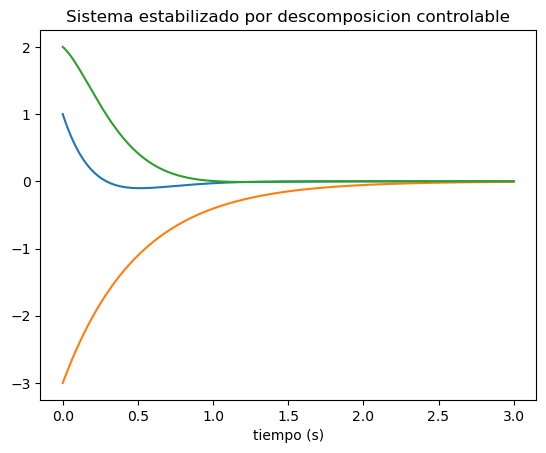

In [20]:
tf = 3
x0 = [1, -3, 2]   # condicion inicial cualquiera

sol = solve_ivp(
    sistema_lineal, [0, tf], x0,
    args=(lambda x: U(R, x), Ai, B),
    max_step=1e-3
)

plt.figure(1)
plt.plot(sol.t, sol.y.T)
plt.xlabel('tiempo (s)')
plt.title('Sistema estabilizado por descomposicion controlable')
plt.show()

El sistema está, por tanto, estabilizado. No era estable, pero sí estabilizable.

Por supuesto, podríamos hacer los cálculos también construyendo un objeto de sistema con `control`, con $C=I_{3\times3}$ y $D=0$.

In [21]:
SYS = ct.ss(Air, B, np.eye(3), 0)
SYS

StateSpace(array([[-4.503 ,  0.    , -1.1834],
       [ 0.    , -2.    ,  0.    ],
       [ 5.0888,  0.    , -3.497 ]]), array([[-1.,  0.],
       [ 0.,  0.],
       [ 1.,  2.]]), array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), array([[0., 0.],
       [0., 0.],
       [0., 0.]]))

Y calculamos la respuesta a las mismas condiciones iniciales de antes con `control.initial_response` (equivalente a `initial` de MATLAB). Ojo: como el sistema tiene 2 entradas y `Air` ya lleva la realimentación incorporada, no hace falta darle entrada, solo la condición inicial.

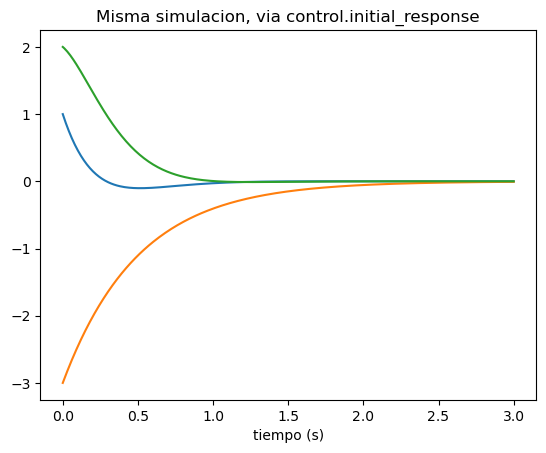

In [22]:
t_out, y_out = ct.initial_response(SYS, T=np.linspace(0, tf, 300), X0=x0)

plt.figure(2)
plt.plot(t_out, y_out.T)
plt.xlabel('tiempo (s)')
plt.title('Misma simulacion, via control.initial_response')
plt.show()